# **Smart Mobility & Ride Analytics**

##1. Does trip distance significantly affect fare amount?

In [6]:
import pandas as pd

df = pd.read_excel("https://raw.githubusercontent.com/karthi-95Entri/Smart-Mobility-Ride-Analytics/refs/heads/main/Trip_Analysis.xlsx")
print(df)

     Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
0                8   270.569350        Shared               2.5   
1               21   275.161032       Economy               2.5   
2               16   359.748971       Economy               2.0   
3               12   264.044264       Premium               1.5   
4                9   225.256916        Shared               2.0   
..             ...          ...           ...               ...   
195              3   352.443261       Premium               1.0   
196             11   200.789306       Premium               2.5   
197             14   418.905411       Premium               1.5   
198             26   304.947881       Economy               1.0   
199             22   255.677793       Economy               1.5   

     Customer_Rating Ride_Time  
0                  3  Non-Peak  
1                  3  Non-Peak  
2                  5  Non-Peak  
3                  5  Non-Peak  
4                  2  Non-Peak

In [10]:
import pandas as pd

correlation = df["Trip_Distance"].corr(df["Fare_Amount"])

covariance = df["Trip_Distance"].cov(df["Fare_Amount"])

from scipy.stats import pearsonr

r, p_value = pearsonr(
    df["Trip_Distance"],
    df["Fare_Amount"]
)


print("Pearson Correlation:", correlation)
print("Covariance:", covariance)
print("P-value:", p_value)

Pearson Correlation: 0.016813110993310898
Covariance: 11.160172520076761
P-value: 0.8132001771984599


##2.	Are premium rides statistically more expensive than economy rides?

In [13]:
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"]
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"]

t_stat, p_value = ttest_ind(
    premium,
    economy,
    equal_var=False
)

economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"]
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"]
shared = df[df["Ride_Category"] == "Shared"]["Fare_Amount"]

f_stat, p_value = f_oneway(
    economy,
    premium,
    shared
)

print("F-statistic:", f_stat)
print("P-value:", p_value)
print("T-statistic:", t_stat)
print("P-value:", p_value)

F-statistic: 0.9284988792342401
P-value: 0.3968686165946833
T-statistic: -0.40600606266641986
P-value: 0.3968686165946833


##3.	Is there a relationship between surge pricing and customer ratings?

In [16]:
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import f_oneway

r, p_value = pearsonr(
    df["Surge_Multiplier"],
    df["Customer_Rating"]
)

groups = [
    group["Customer_Rating"].values
    for _, group in df.groupby("Surge_Multiplier")
]

f_stat, p_value = f_oneway(*groups)


print("Pearson Correlation:", r)
print("P-value:", p_value)
print("F-statistic:", f_stat)
print("P-value:", p_value)

Pearson Correlation: -0.041303784013180425
P-value: 0.08879354834920444
F-statistic: 2.2049312918332387
P-value: 0.08879354834920444


##4.	Do peak-hour rides differ in revenue compared to non-peak rides?

Summary Statistics-
Peak Rides: Count = 103, Mean = 257.07, Std Dev = 74.40
Non-Peak Rides: Count = 97, Mean = 263.75, Std Dev = 83.29

Hypothesis Test Results-
t-statistic: -0.5965
p-value: 0.5515
Conclusion: Fail to reject the null hypothesis. No statistically significant difference in revenue.


/tmp/ipykernel_2122/2031262311.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ride_Time', y='Fare_Amount', data=df, palette='Set2')


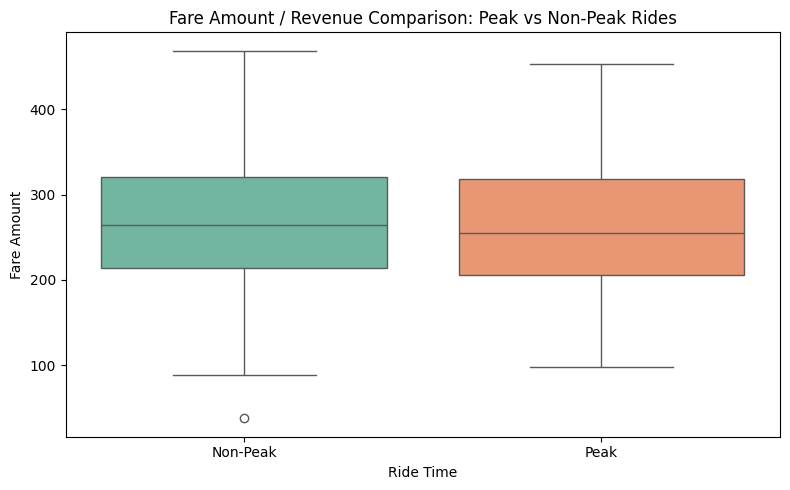

In [24]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

peak_fares = df[df['Ride_Time'] == 'Peak']['Fare_Amount']
non_peak_fares = df[df['Ride_Time'] == 'Non-Peak']['Fare_Amount']

print("Summary Statistics-")
print(f"Peak Rides: Count = {len(peak_fares)}, Mean = {peak_fares.mean():.2f}, Std Dev = {peak_fares.std():.2f}")
print(f"Non-Peak Rides: Count = {len(non_peak_fares)}, Mean = {non_peak_fares.mean():.2f}, Std Dev = {non_peak_fares.std():.2f}\n")

t_stat, p_val = stats.ttest_ind(peak_fares, non_peak_fares, equal_var=False)

print("Hypothesis Test Results-")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant difference in revenue.")
else:
    print("Conclusion: Fail to reject the null hypothesis. No statistically significant difference in revenue.")


plt.figure(figsize=(8, 5))
sns.boxplot(x='Ride_Time', y='Fare_Amount', data=df, palette='Set2')
plt.title('Fare Amount / Revenue Comparison: Peak vs Non-Peak Rides')
plt.xlabel('Ride Time')
plt.ylabel('Fare Amount')
plt.tight_layout()
plt.show()

##5.	Are there unusual fare values that indicate anomalies or pricing errors?


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

fare = df["Fare_Amount"].dropna()

Q1 = fare.quantile(0.25)
Q2 = fare.quantile(0.50)
Q3 = fare.quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Fare_ZScore"] = zscore(df["Fare_Amount"].fillna(df["Fare_Amount"].median()))

# Identify extreme values
z_outliers = df[
    df["Fare_ZScore"].abs() > 3
]

print("Q1 (25th percentile):", Q1)
print("Median (50th percentile):", Q2)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

iqr_outliers = df[
    (df["Fare_Amount"] < lower_bound) |
    (df["Fare_Amount"] > upper_bound)
]


df["IQR_Outlier"] = (
    (df["Fare_Amount"] < lower_bound) |
    (df["Fare_Amount"] > upper_bound)
)

df["ZScore_Outlier"] = df["Fare_ZScore"].abs() > 3

combined_outliers = df[
    df["IQR_Outlier"] | df["ZScore_Outlier"]
]

percentiles = fare.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

print("\nNumber of IQR outliers:", len(iqr_outliers))
print("Fare Percentiles:")
print(percentiles)
print("Number of Z-score outliers:", len(z_outliers))
print("\nExtreme fare values:")
print(
    z_outliers[
        ["Fare_Amount", "Fare_ZScore"]
    ].sort_values("Fare_Amount")
)


print("Total unusual fares:", len(combined_outliers))
print(
    combined_outliers[
        ["Fare_Amount", "Fare_ZScore",
         "IQR_Outlier", "ZScore_Outlier"]
    ].sort_values("Fare_Amount")
)
print("Fare Summary Statistics")
print(fare.describe(percentiles=[
    0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99
]))


Q1 (25th percentile): 208.5288261048614
Median (50th percentile): 256.90710336367647
Q3 (75th percentile): 319.7637824819526
IQR: 111.23495637709121

Lower Bound: 41.67639153922457
Upper Bound: 486.61621704758943

Number of IQR outliers: 1
Fare Percentiles:
0.01     90.381192
0.05    137.353034
0.25    208.528826
0.50    256.907103
0.75    319.763782
0.95    383.085351
0.99    441.242978
Name: Fare_Amount, dtype: float64
Number of Z-score outliers: 0

Extreme fare values:
Empty DataFrame
Columns: [Fare_Amount, Fare_ZScore]
Index: []
Total unusual fares: 1
    Fare_Amount  Fare_ZScore  IQR_Outlier  ZScore_Outlier
10    37.585916     -2.83695         True           False
Fare Summary Statistics
count    200.000000
mean     260.312376
std       78.706127
min       37.585916
1%        90.381192
5%       137.353034
25%      208.528826
50%      256.907103
75%      319.763782
95%      383.085351
99%      441.242978
max      468.753773
Name: Fare_Amount, dtype: float64


##6.	Can ride demand probabilities be estimated for different ride categories?

In [32]:
import pandas as pd

category_counts = df["Ride_Category"].value_counts()

total_rides = len(df)

category_probability = category_counts / total_rides

conditional_probability = pd.crosstab(
    df["Fare_Amount"],
    df["Ride_Category"],
    normalize="index"
)

bayes_table = pd.crosstab(
    df["Ride_Category"],
    df["Fare_Amount"],
    normalize="index"
)

print("Ride Category Probabilities:")
print(category_probability)
print("Conditional Probability:")
print(conditional_probability)
print("Bayes / Reverse Conditional Probability:")
print(bayes_table)

Ride Category Probabilities:
Ride_Category
Economy    0.41
Shared     0.30
Premium    0.29
Name: count, dtype: float64
Conditional Probability:
Ride_Category  Economy  Premium  Shared
Fare_Amount                            
37.585916          1.0      0.0     0.0
88.214805          1.0      0.0     0.0
90.403074          0.0      1.0     0.0
98.209841          0.0      1.0     0.0
106.920280         0.0      1.0     0.0
...                ...      ...     ...
418.905411         0.0      1.0     0.0
437.839754         0.0      0.0     1.0
441.122877         0.0      0.0     1.0
453.133017         0.0      0.0     1.0
468.753773         0.0      0.0     1.0

[200 rows x 3 columns]
Bayes / Reverse Conditional Probability:
Fare_Amount    37.585916   88.214805   90.403074   98.209841   106.920280  \
Ride_Category                                                               
Economy          0.012195    0.012195    0.000000    0.000000    0.000000   
Premium          0.000000    0.000000   

##7.	Which operational factors are most strongly related to business performance?

In [38]:
import pandas as pd
import numpy as np

numeric_df = df.select_dtypes(include="number").copy()

print("Numerical variables:")
print(numeric_df.columns.tolist())

numeric_df = numeric_df.drop(
    columns=["Trip_ID"],
    errors="ignore"
)
pearson_corr = numeric_df.corr(method="pearson")

print("Pearson Correlation Matrix:")
print(pearson_corr.round(3))
fare_pearson = (
    pearson_corr["Fare_Amount"]
    .drop("Fare_Amount")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("Pearson correlations with Fare Amount:")
print(fare_pearson)

spearman_corr = numeric_df.corr(method="spearman")

print("Spearman Correlation Matrix:")
print(spearman_corr.round(3))

fare_spearman = (
    spearman_corr["Fare_Amount"]
    .drop("Fare_Amount")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("Spearman correlations with Fare Amount:")
print(fare_spearman)

covariance_matrix = numeric_df.cov()

print("Covariance Matrix:")
print(covariance_matrix.round(3))

fare_covariance = (
    covariance_matrix["Fare_Amount"]
    .drop("Fare_Amount")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("Covariance with Fare Amount:")
print(fare_covariance)

from sklearn.preprocessing import StandardScaler
analysis_df = numeric_df.dropna()
scaler = StandardScaler()

scaled_data = scaler.fit_transform(analysis_df)
corr_matrix = np.corrcoef(
    scaled_data,
    rowvar=False
)

eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

sorted_eigenvalues = np.sort(
    eigenvalues
)[::-1]

print("Eigenvalues:")
print(sorted_eigenvalues)

explained_variance = (
    sorted_eigenvalues /
    sorted_eigenvalues.sum()
)

cumulative_variance = np.cumsum(
    explained_variance
)

eigenvalue_table = pd.DataFrame({
    "Eigenvalue": sorted_eigenvalues,
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

print(eigenvalue_table.round(3))

Numerical variables:
['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating', 'Fare_ZScore']
Pearson Correlation Matrix:
                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance             1.000        0.017             0.017   
Fare_Amount               0.017        1.000             0.017   
Surge_Multiplier          0.017        0.017             1.000   
Customer_Rating          -0.085        0.053            -0.041   
Fare_ZScore               0.017        1.000             0.017   

                  Customer_Rating  Fare_ZScore  
Trip_Distance              -0.085        0.017  
Fare_Amount                 0.053        1.000  
Surge_Multiplier           -0.041        0.017  
Customer_Rating             1.000        0.053  
Fare_ZScore                 0.053        1.000  
Pearson correlations with Fare Amount:
Fare_ZScore         1.000000
Customer_Rating     0.052723
Surge_Multiplier    0.017419
Trip_Distance       0.016813
Name: Fare_Amount,

##8.	Can statistical evidence support pricing or service improvements?

In [51]:
from scipy import stats

fare = df["Fare_Amount"].dropna()

mean_fare = fare.mean()
n = len(fare)
std_fare = fare.std()

confidence = 0.95
alpha = 1 - confidence

t_critical = stats.t.ppf(1 - alpha / 2, df=n-1)

margin_error = t_critical * (std_fare / np.sqrt(n))

lower = mean_fare - margin_error
upper = mean_fare + margin_error

print("Mean Fare:", mean_fare)
print("95% Confidence Interval:", (lower, upper))

bootstrap_means = []

for i in range(5000):
    sample = np.random.choice(
        fare,
        size=len(fare),
        replace=True
    )

    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

lower_bootstrap = np.percentile(bootstrap_means, 2.5)
upper_bootstrap = np.percentile(bootstrap_means, 97.5)

print("Bootstrap Mean:", bootstrap_means.mean())
print("95% Bootstrap CI:",
      (lower_bootstrap, upper_bootstrap))

test_value = 250

t_stat, p_value = stats.ttest_1samp(
    fare,
    test_value
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

    category1 = df[df["Ride_Category"] == "Economy"]["Fare_Amount"].dropna()
category2 = df[df["Ride_Category"] == "Premium"]["Fare_Amount"].dropna()

t_stat, p_value = stats.ttest_ind(
    category1,
    category2,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean Fare: 260.31237600443757
95% Confidence Interval: (np.float64(249.33772077198984), np.float64(271.2870312368853))
Bootstrap Mean: 260.3180866990374
95% Bootstrap CI: (np.float64(249.53919686309388), np.float64(271.03033273595264))
T-statistic: 1.8529563724778202
P-value: 0.06536923035541557
Fail to reject H0
T-statistic: 0.40600606266641986
P-value: 0.6854530831483114
